#**Capstone project: Can ML Outperform Market-Neutral Trading in Structural Breaks?**

**Note:**

It's always a good practise to "restart the session", whenever changes are made to github repository


##**Step 1:** GitHub setup

1) Clone/Update the projects github repository

In [1]:
# Use for the first time to clone the github repo or when the repo is updated
%rm -rf /content/MarketNeutral_Trading/
%cd /content
!git clone https://github.com/WQU-Capstone-11205/MarketNeutral_Trading.git
%cd /content/MarketNeutral_Trading

/content
Cloning into 'MarketNeutral_Trading'...
remote: Enumerating objects: 694, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 694 (delta 83), reused 4 (delta 4), pack-reused 556 (from 1)
Receiving objects: 100% (694/694), 465.78 KiB | 16.63 MiB/s, done.
Resolving deltas: 100% (386/386), done.
/content/MarketNeutral_Trading


2) Add the project's github repository's path to the system path

In [2]:
import sys
sys.path.append('/content/MarketNeutral_Trading')

3) Install projects required packages

In [3]:
!pip install -r requirements.txt

In [4]:
import warnings
warnings.filterwarnings('ignore')

##**Step 2:** Data loading

Load data and convert to distance spread

In [5]:
from data_loading.distance_spread import distance_spread
from util.split_time_series import split_time_series

tickers = ["KO", "PEP"]
spread = distance_spread(tickers, start_date="2005-01-01", end_date="2025-01-01")
train_spread, test_spread = split_time_series(spread)

[*********************100%***********************]  2 of 2 completed


##**Step 3:** Hyperparameter tuning of BOCPD+VAE+LSTM pipeline

Tune hyper-parameter for BOCPD+VAE+LSTM pipeline.

In [19]:
from tuning.bocpd_vae_lstm_tuner import BOCPD_VAE_LSTM_Tuner

bocpd_space = {
    "hazard": [50],
    "mu": [0],
    "kappa": [0.1], #10.0
    "alpha": [1.0], #10.0
    "beta": [0.1] #10.0
}

vae_space = {
    "input_dim": [3],
    "latent_dim": [16],
    "hidden_dim": [256],
    "lr": [1e-3],
    "vae_seq_len": [1], #, 5, 15, 25
    "kl_wt": [0.01]
}

lstm_space = {
    "z_dim": [16],
    "hidden_dim": [512],
    "lr": [5e-6]
}

joint_space = {
    "state_window": [25], #50
    "base_action_sigma": [0.1],#0.3
    "wt_multplier": [1.5], #1.5
    "buffer_size_updates": [128], #256
    "sample_batch_size": [16] #128
}

bocpd_vae_lstm_tuner = BOCPD_VAE_LSTM_Tuner(bocpd_space, vae_space, lstm_space, joint_space)

bocpd_vae_lstm_tuner.tune(train_spread)
bocpd_params, vae_params, lstm_params, joint_params = bocpd_vae_lstm_tuner.best_params

print(f'bocpd_params = {bocpd_params}')
print(f'vae_params = {vae_params}')
print(f'lstm_params = {lstm_params}')
print(f'joint_params = {joint_params}')

bocpd score = -17 :: params = {'hazard': 50, 'mu': 0, 'kappa': 0.1, 'alpha': 1.0, 'beta': 0.1}
Best BOCPD parameters: {'hazard': 50, 'mu': 0, 'kappa': 0.1, 'alpha': 1.0, 'beta': 0.1}
Best BOCPD score: -17
vae score = -165.9267 :: params = {'input_dim': 3, 'latent_dim': 16, 'hidden_dim': 256, 'lr': 0.001, 'vae_seq_len': 1, 'kl_wt': 0.01}
Best vae parameters: {'input_dim': 3, 'latent_dim': 16, 'hidden_dim': 256, 'lr': 0.001, 'vae_seq_len': 1, 'kl_wt': 0.01}
Best vae score: -165.9267
LSTM score = -2.329 :: params = {'z_dim': 16, 'hidden_dim': 512, 'lr': 5e-06}
Best LSTM parameters: {'z_dim': 16, 'hidden_dim': 512, 'lr': 5e-06}
Best LSTM score: -2.329
Joint Tuning score = -4.893 :: params = {'state_window': 25, 'base_action_sigma': 0.1, 'wt_multplier': 1.5, 'buffer_size_updates': 128, 'sample_batch_size': 16}
Best Joint Tuning parameters: {'state_window': 25, 'base_action_sigma': 0.1, 'wt_multplier': 1.5, 'buffer_size_updates': 128, 'sample_batch_size': 16}
Best Joint Tuning score: -4.893


##**Step 4:** Training of BOCPD+VAE+LSTM pipeline

In [20]:
from train.train_loop_lstm import train_loop_lstm

train_loop_lstm(train_spread, bocpd_params, vae_params, lstm_params, joint_params, num_epochs=10)

100%|██████████| 3522/3522 [02:24<00:00, 24.43it/s]


Epoch 000 | recon=0.0423 | kl=0.5667 | policy=0.0003
Sharpe = -0.280
Saved all models + optimizers
Saved best models at epoch 000 (Sharpe=-0.280)


100%|██████████| 3522/3522 [02:25<00:00, 24.20it/s]


Epoch 001 | recon=0.0100 | kl=0.6312 | policy=0.0006
Sharpe = -0.290


100%|██████████| 3522/3522 [02:29<00:00, 23.55it/s]


...

Epoch 007 | recon=0.0026 | kl=0.5055 | policy=0.0008
Sharpe = -0.412


100%|██████████| 3522/3522 [02:40<00:00, 21.98it/s]


Epoch 008 | recon=0.0026 | kl=0.4898 | policy=0.0010
Sharpe = -0.417


100%|██████████| 3522/3522 [02:41<00:00, 21.79it/s]


Epoch 009 | recon=0.0025 | kl=0.4924 | policy=0.0010
Sharpe = -0.382
LSTM policy training complete.


##**Step 5:** Testing of BOCPD+VAE+LSTM pipeline:

In [21]:
from backtest.evaluate_loop_lstm import evaluate_loop_lstm

lstm_test_metrics = evaluate_loop_lstm(test_spread, bocpd_params, vae_params, lstm_params, joint_params)

Loaded models/opts


100%|██████████| 1509/1509 [00:06<00:00, 246.27it/s]


Evaluation complete.


##**Step 6:** Test metrics BOCPD+VAE+LSTM pipeline:

In [22]:
import numpy as np
from util.metrics import sharpe_ratio, compute_max_drawdown, sortino_ratio, annual_volatility, alpha_beta

print("Test metrics:")
print(f"Cummulative profit and loss             : {lstm_test_metrics['pnl'][-1]:.6f}")
print(f"Sharpe ratio (RL Profit and Loss)       : {sharpe_ratio(np.diff(lstm_test_metrics['pnl'])):.6f}")
print(f"Sharpe ratio (Buy and Hold)             : {sharpe_ratio(np.diff(test_spread)):.6f}")
print(f"Sortino ratio (RL)                      : {sortino_ratio(np.diff(lstm_test_metrics['pnl'])):.6f}")
print(f"Sortino ratio (Buy and Hold)            : {sortino_ratio(np.diff(test_spread)):.6f}")
print(f"Max drawdown (RL Profit and Loss)       : {compute_max_drawdown(lstm_test_metrics['pnl']):.6f}")
print(f"Max drawdown (Buy and Hold)             : {compute_max_drawdown(test_spread):.6f}")
print(f"Annual Volatility (RL Profit and Loss)  : {annual_volatility(lstm_test_metrics['pnl']):.6f}")
print(f"Annual Volatility (Buy and Hold)        : {annual_volatility(test_spread):.6f}")
alpha, beta = alpha_beta(lstm_test_metrics['pnl'], test_spread)
print(f"Alpha Beta (RL Profit and Loss)         : alpha = {alpha:.6f} , beta = {beta:.6f}")

Test metrics:
Cummulative profit and loss             : -0.030423
Sharpe ratio (RL Profit and Loss)       : 0.002437
Sharpe ratio (Buy and Hold)             : -0.005051
Sortino ratio (RL)                      : 0.003095
Sortino ratio (Buy and Hold)            : -0.007094
Max drawdown (RL Profit and Loss)       : 2.395467
Max drawdown (Buy and Hold)             : 4.101381
Annual Volatility (RL Profit and Loss)  : 2.837960
Annual Volatility (Buy and Hold)        : 59.523600
Alpha Beta (RL Profit and Loss)         : alpha = 1.900492 , beta = 0.002641


##**Step 7:** Plots for BOCPD+VAE+LSTM pipeline
##7.1) **Original vs Reconstructed Spread:**

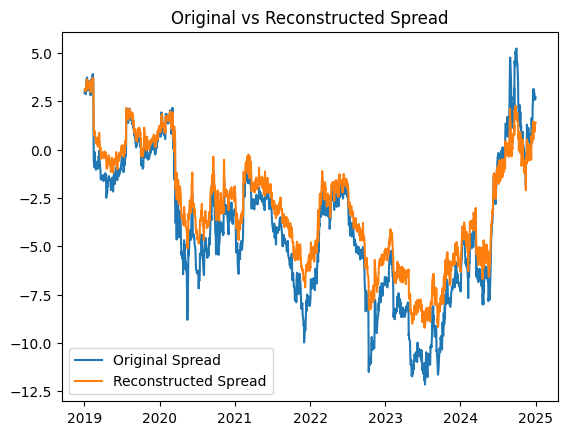

In [23]:
import matplotlib.pyplot as plt

plt.plot(test_spread.index, test_spread, label="Original Spread")
plt.plot(test_spread.index, lstm_test_metrics['recons'], label="Reconstructed Spread")
plt.legend();
plt.title("Original vs Reconstructed Spread")
plt.show()

## 7.2) **Drawdown for PnL and Buy & Hold:**

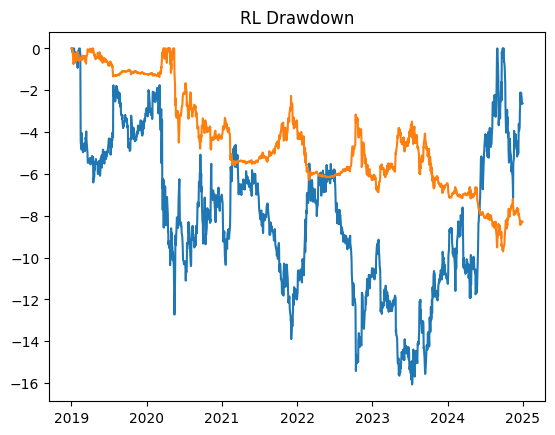

In [24]:
sz = len(test_spread)
cum_pnl_rl = np.cumsum(lstm_test_metrics['pnl'])
rolling_max_rl = np.maximum.accumulate(cum_pnl_rl)
drawdown_rl = cum_pnl_rl - rolling_max_rl
cum_pnl_bh = test_spread
rolling_max_bh = np.maximum.accumulate(cum_pnl_bh)
drawdown_bh = cum_pnl_bh - rolling_max_bh
plt.plot(test_spread.index[:sz-1],drawdown_bh[:sz-1], label="Buy&Hold")
plt.plot(test_spread.index[:sz-1], drawdown_rl, label="RL")
plt.title("RL Drawdown")
plt.show()


## 7.3) **Change Probability over time plot for BOCPD+VAE+RL pipeline:**

np.sum(change_probs > 0.5) = 47
Total len of change_probs = 1509


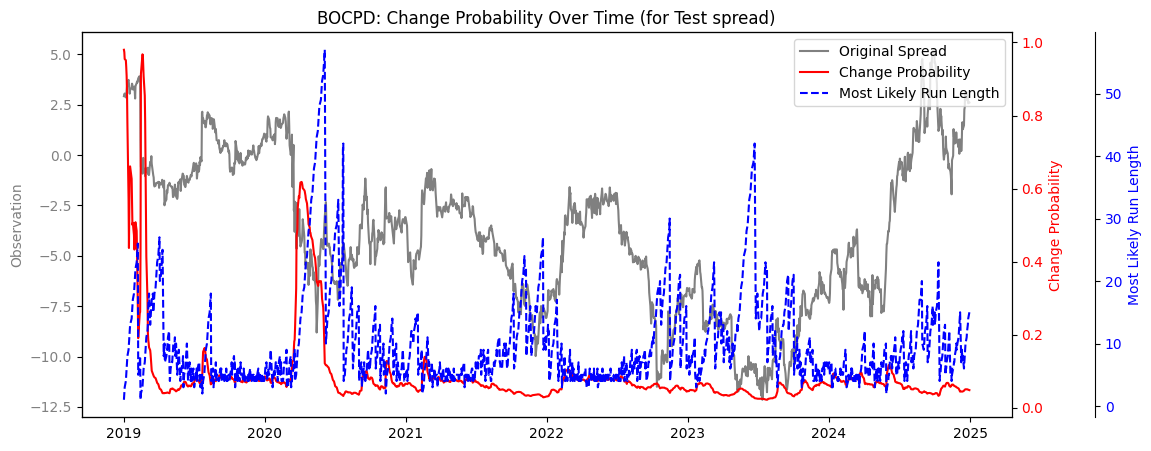

In [25]:
from plots.bocpd import plot_rt_change_probs

plot_rt_change_probs(test_spread, lstm_test_metrics['rt_mle'], lstm_test_metrics['change_probs'])